In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from google.colab import files

uploaded = files.upload()

Saving Housing.csv to Housing.csv


In [7]:
import pandas as pd

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [9]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestro

In [10]:
encoder = LabelEncoder()

categorical_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 0  
1                 0  
2                 1  
3                 0  
4                 0  


In [11]:
X = df.drop('price', axis=1)

y = df['price']

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Complete")

Model Training Complete


In [15]:
y_pred = model.predict(X_test)

print("Sample Predictions:\n")

for i in range(10):
    print(f"Actual: {y_test.iloc[i]} | Predicted: {int(y_pred[i])}")

Sample Predictions:

Actual: 4060000 | Predicted: 5203691
Actual: 6650000 | Predicted: 7257004
Actual: 3710000 | Predicted: 3062828
Actual: 6440000 | Predicted: 4559591
Actual: 2800000 | Predicted: 3332932
Actual: 4900000 | Predicted: 3563080
Actual: 5250000 | Predicted: 5645466
Actual: 4543000 | Predicted: 6413979
Actual: 2450000 | Predicted: 2755831
Actual: 3353000 | Predicted: 2668938


In [16]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)

print("MSE:", mse)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 979679.6912959907
MSE: 1771751116594.04
RMSE: 1331071.4167895124
R2 Score: 0.6494754192267793


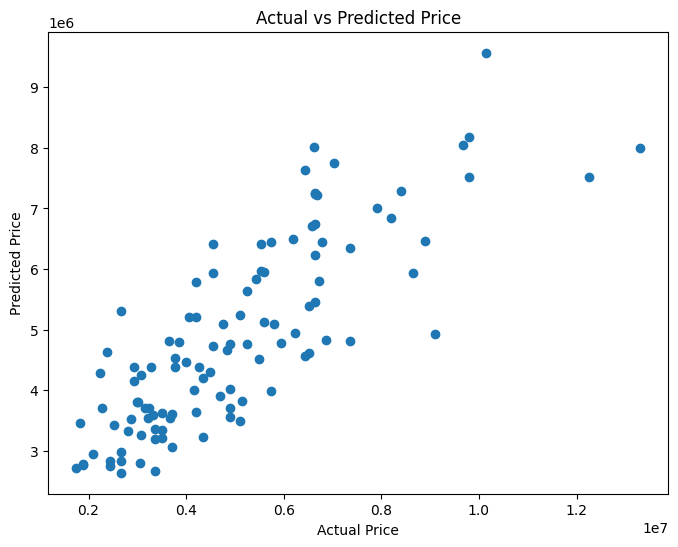

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

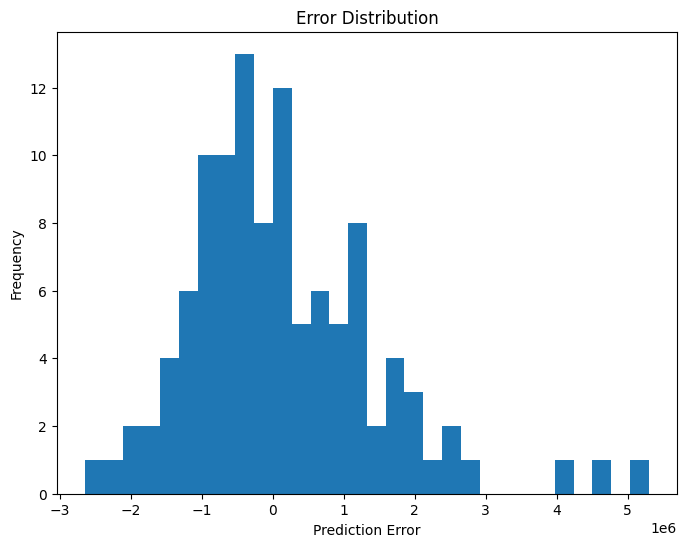

In [18]:
errors = y_test - y_pred

plt.figure(figsize=(8,6))

plt.hist(errors, bins=30)

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.title("Error Distribution")

plt.show()

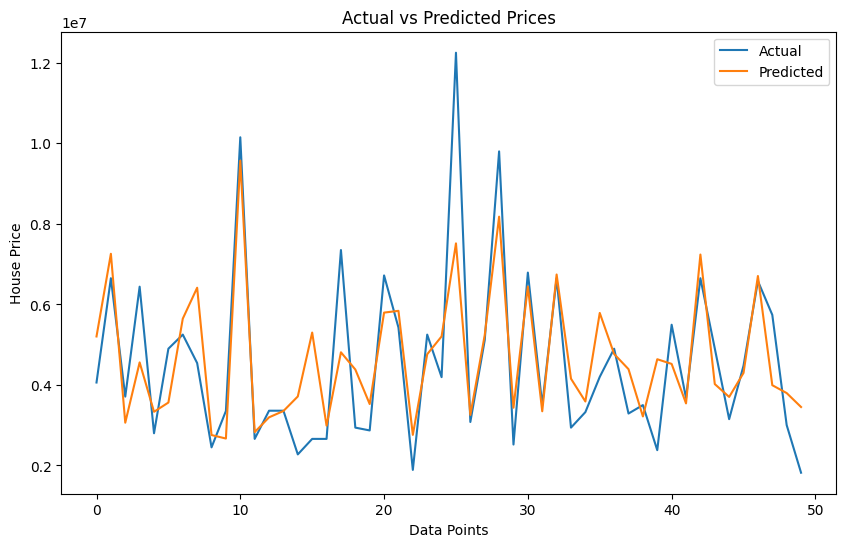

In [19]:
plt.figure(figsize=(10,6))

plt.plot(range(50), y_test.iloc[:50].values, label='Actual')

plt.plot(range(50), y_pred[:50], label='Predicted')

plt.xlabel('Data Points')

plt.ylabel('House Price')

plt.title('Actual vs Predicted Prices')

plt.legend()

plt.show()